# Mirror-CFE Decoder Training — Chest X-Ray


## 1. Imports & Konfiguration

In [1]:
import os
import time
import numpy as np
import pandas as pd
from glob import glob
from pathlib import Path
from tqdm import tqdm
from collections import OrderedDict
from functools import partial

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit

torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Gerät:', DEVICE)

# ── Pfade (identisch zum Mirror-XRAY-Eval-Notebook) ───────────────────────────
CSV_PATH   = '../input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
BBOX_PATH  = '../input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv'
IMAGE_GLOB = '../input/datasets/organizations/nih-chest-xrays/data/images_*/images/*.png'
PTH_PATH   = '/kaggle/input/models/alexandernigg/resnet18-updated/pytorch/default/1/resnet18_xray_final.pth'
OUT_DIR    = '/kaggle/working'

IMG_SIZE      = 224
BATCH_SIZE    = 16
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
# Explizit gesetzt (NICHT alphabetisch): No Finding=0, Infiltration=1
CLASS_NAMES   = {0: 'No Finding', 1: 'Infiltration'}

# ── Mirror-Decoder Hyperparameter ─────────────────────────────────────────────
DEC_LR      = 2e-4          # Paper: Adam, 2e-4
DISC_LR     = 2e-4
DEC_EPOCHS  = 5            # Paper CelebA: 30 Epochen
ALPHA       = 0.2          # Triangulation-Relaxation (Paper-Default)
RHO_L       = 0.1          # CSP Maskenschwelle untere Grenze
RHO_U       = 0.5          # CSP Maskenschwelle obere Grenze

# Loss-Gewichte (Paper: gleich, ausser L_tri=2 für farbige/grosse Bilder)
W_CLS  = 1.0
W_ADV  = 1.0
W_REC  = 1.0
W_FEA  = 1.0
W_TRI  = 2.0

print('CSV    vorhanden:', os.path.exists(CSV_PATH))
print('BBox   vorhanden:', os.path.exists(BBOX_PATH))
print('Modell vorhanden:', os.path.exists(PTH_PATH))


Gerät: cuda
CSV    vorhanden: True
BBox   vorhanden: True
Modell vorhanden: True


## 2. Datensatz laden & patientenbasierter Split

In [2]:
# ── CSV laden, Binärlabel zuweisen (No Finding=0, Infiltration=1) ─────────────
all_xray_df = pd.read_csv(CSV_PATH)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

def assign_binary_label(finding: str):
    if finding == 'No Finding':
        return 0
    elif 'Infiltration' in finding:
        return 1
    return None

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)
all_xray_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
all_xray_df['binary_label'] = all_xray_df['binary_label'].astype(int)

counts = all_xray_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Infiltration'})
print('Klassenverteilung gesamt:')
print(counts)

# ── Patientenbasierter Split — IDENTISCH zum Eval-Notebook (random_state=42) ──
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter.split(all_xray_df, groups=all_xray_df['Patient ID']))
train_df = all_xray_df.iloc[train_idx].reset_index(drop=True)
temp_df  = all_xray_df.iloc[temp_idx].reset_index(drop=True)
splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(splitter2.split(temp_df, groups=temp_df['Patient ID']))
valid_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)

# Patienten-Disjunktheit sicherstellen (kein Leakage in den Decoder)
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID'])) == 0
assert len(set(train_df['Patient ID']) & set(valid_df['Patient ID'])) == 0
print(f'Train: {len(train_df)}  Val: {len(valid_df)}  Test: {len(test_df)}')
print('Train-Verteilung:', train_df['binary_label'].value_counts().to_dict())


Klassenverteilung gesamt:
binary_label
No Finding      60361
Infiltration    19894
Name: count, dtype: int64
Train: 56768  Val: 11926  Test: 11561
Train-Verteilung: {0: 42624, 1: 14144}


## 3. DataLoader (XRayDataset, Train mit Augmentierung + Klassen-Balancing)

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),   # mild für Graustufen-Röntgen
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class XRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = int(row['binary_label'])
        fname = row['Image Index']
        if self.transform:
            image = self.transform(image)
        return image, label, fname

train_dataset = XRayDataset(train_df, transform=train_transforms)
val_dataset   = XRayDataset(valid_df, transform=eval_transforms)

# ── Klassen-Balancing (Infiltration ist Minderheit) ───────────────────────────
train_labels  = train_df['binary_label'].values
n0 = int((train_labels == 0).sum())
n1 = int((train_labels == 1).sum())
print(f'Train — No Finding: {n0}  Infiltration: {n1}')
weights_per_class = [1.0 / max(n0, 1), 1.0 / max(n1, 1)]
sample_weights    = [weights_per_class[l] for l in train_labels]
sampler = WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.float32),
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

imgs, lbls, _ = next(iter(train_loader))
print('Batch:', imgs.shape, '| Labels:', torch.unique(lbls, return_counts=True))
print(f'Train-Batches: {len(train_loader)}  Val-Batches: {len(val_loader)}')


Train — No Finding: 42624  Infiltration: 14144
Batch: torch.Size([16, 3, 224, 224]) | Labels: (tensor([0, 1]), tensor([ 5, 11]))
Train-Batches: 3548  Val-Batches: 746


## 4. Klassifikator laden

In [4]:
class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_classifier():
    return ResNet(in_channels=3, n_classes=2,
                  block=ResNetBasicBlock, depths=[2, 2, 2, 2])

checkpoint  = torch.load(PTH_PATH, map_location=DEVICE, weights_only=False)
classifier  = build_classifier().to(DEVICE)
classifier.load_state_dict(checkpoint.get('model_state_dict', checkpoint))
classifier.eval()
for param in classifier.parameters():
    param.requires_grad = False

print('Klassifikator geladen und eingefroren ✓')
print(f'Test-AUC:      {checkpoint.get("test_auc", "N/A")}')
print(f'Test-Accuracy: {checkpoint.get("test_accuracy", "N/A")}')


Klassifikator geladen und eingefroren ✓
Test-AUC:      0.7513
Test-Accuracy: 0.6863


## 5. Feature-Extraktion & Mirror-Geometrie


In [5]:
def extract_all_features(model, images):
    """Feature Maps aus allen 4 ResNet-Ebenen.
       f1:(B,64,56,56) f2:(B,128,28,28) f3:(B,256,14,14) f4:(B,512,7,7)"""
    feats = {}
    hooks = []
    layer_map = {
        'f1': model.encoder.blocks[0],
        'f2': model.encoder.blocks[1],
        'f3': model.encoder.blocks[2],
        'f4': model.encoder.blocks[3],
    }
    for name, layer in layer_map.items():
        h = layer.register_forward_hook(
            lambda m, i, o, n=name: feats.update({n: o})
        )
        hooks.append(h)
    with torch.no_grad():
        _ = model(images)
    for h in hooks:
        h.remove()
    return feats['f1'], feats['f2'], feats['f3'], feats['f4']

def get_boundary_params(model):
    """Mirror-Hyperebene: Wm = W[1]-W[0], bm = b[1]-b[0] (Richtung Klasse 1)."""
    W  = model.decoder.decoder.weight.data   # (2, 512)
    b  = model.decoder.decoder.bias.data     # (2,)
    Wm = (W[1] - W[0]).clone()               # (512,)
    bm = (b[1] - b[0]).clone()               # scalar
    return Wm, bm

def gap(fmap):
    return F.adaptive_avg_pool2d(fmap, (1, 1)).flatten(1)

def compute_flk(f4_s, zs, Wm, bm, k):
    """Supp. Eq. 16/17: f^l_k = f^l_s + z_Δ, mit z_Δ broadcast über H,W.
       Garantiert GAP(f^l_k) = z_k."""
    B, C, H, Wd = f4_s.shape
    W_hat = Wm / (Wm.norm() + 1e-8)                       # (C,)
    dot   = (Wm.view(1, C) * zs).sum(1, keepdim=True) + bm  # (B,1)
    z_delta = -2.0 * k * dot * W_hat.view(1, C)            # (B,C)
    zk  = zs + z_delta                                     # (B,C)
    flk = f4_s + z_delta.view(B, C, 1, 1)                  # broadcast (B,C,H,W)
    return flk, zk

def predict_probs_from_z(model, z):
    """Softmax-Wahrscheinlichkeiten direkt aus einem GAP-Latent z (B,512)."""
    return torch.softmax(model.decoder.decoder(z), dim=1)

# Sanity Check: GAP(f^l_k) == z_k
with torch.no_grad():
    _imgs, _, _ = next(iter(val_loader))
    _imgs = _imgs.to(DEVICE)
    _f1, _f2, _f3, _f4 = extract_all_features(classifier, _imgs)
    _zs = gap(_f4)
    _Wm, _bm = get_boundary_params(classifier); _Wm, _bm = _Wm.to(DEVICE), _bm.to(DEVICE)
    _flk, _zk = compute_flk(_f4, _zs, _Wm, _bm, k=0.8)
    err = (gap(_flk) - _zk).abs().max().item()
    print(f'Sanity: max|GAP(f^l_k) - z_k| = {err:.2e}  (sollte ~0 sein) ✓')


Sanity: max|GAP(f^l_k) - z_k| = 1.19e-07  (sollte ~0 sein) ✓


## 6. Skip-Connection-Controller (SSC)

In [6]:
class SPEBlock(nn.Module):
    """Spatial Pattern Editor für eine Skip-Ebene (Paper Eq. 12)."""
    def __init__(self, Ci, Hi, flk_ch=512, bottleneck_ch=128):
        super().__init__()
        self.Hi = Hi
        # B_i: Quell-Skip-Feature → (bottleneck_ch, 7, 7)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(Ci, bottleneck_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(bottleneck_ch),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((7, 7)),
        )
        # D_i: concat(bottleneck, f^l_k) → zurück auf (Ci, Hi, Hi)
        self.decoder = nn.Sequential(
            nn.Conv2d(bottleneck_ch + flk_ch, Ci, kernel_size=3, padding=1),
            nn.BatchNorm2d(Ci),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(Hi, Hi), mode='bilinear', align_corners=False),
            nn.Conv2d(Ci, Ci, kernel_size=3, padding=1),
            nn.BatchNorm2d(Ci),
            nn.ReLU(inplace=True),
        )
    def forward(self, fi_s, flk):
        bi  = self.bottleneck(fi_s)             # (B, bn, 7, 7)
        cat = torch.cat([bi, flk], dim=1)       # (B, bn+512, 7, 7)
        ui  = self.decoder(cat)                 # (B, Ci, Hi, Hi)
        return ui


class SSC(nn.Module):
    """Skip-Connection-Controller = SPE (3 Ebenen) + CSP-Maskierung."""
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.rho_l = rho_l
        self.rho_u = rho_u
        # SPE-Blöcke für f1,f2,f3 (f4 = f^l_k ist Haupteingang, kein SPE nötig)
        self.spe1 = SPEBlock(64,  56)
        self.spe2 = SPEBlock(128, 28)
        self.spe3 = SPEBlock(256, 14)

    def csp_mask(self, flk, W, k, target_hw, src_cls, tgt_cls):
        """Eq. 13: CAM-Union-Maske, hochskaliert auf target_hw.
           src_cls/tgt_cls: (B,) Tensoren mit der Quell-/Zielklasse pro Sample."""
        B, C, H, Wd = flk.shape
        Uk = torch.einsum('oc,bchw->bohw', W, flk)        # (B,|C|,7,7)
        Uk = F.relu(Uk)
        mx = Uk.amax(dim=(2, 3), keepdim=True) + 1e-8
        Nk = Uk / mx                                       # (B,|C|,7,7) in [0,1]
        rho = min(max(1.0 - k, self.rho_l), self.rho_u)
        idx = torch.arange(B, device=flk.device)
        Ns = (Nk[idx, src_cls].unsqueeze(1) > rho).float() # (B,1,7,7)
        Nt = (Nk[idx, tgt_cls].unsqueeze(1) > rho).float()
        M  = torch.clamp(Ns + Nt, 0.0, 1.0)                # Union
        M  = F.interpolate(M, size=target_hw, mode='nearest')
        return M

    def forward(self, f1_s, f2_s, f3_s, flk, W, k, src_cls, tgt_cls):
        # SPE: editierte Skip-Features
        u1 = self.spe1(f1_s, flk)
        u2 = self.spe2(f2_s, flk)
        u3 = self.spe3(f3_s, flk)
        # CSP: Masken pro Ebene
        m1 = self.csp_mask(flk, W, k, (56, 56), src_cls, tgt_cls)
        m2 = self.csp_mask(flk, W, k, (28, 28), src_cls, tgt_cls)
        m3 = self.csp_mask(flk, W, k, (14, 14), src_cls, tgt_cls)
        # Mischung (Eq. 14)
        fp1 = (1 - m1) * f1_s + m1 * u1
        fp2 = (1 - m2) * f2_s + m2 * u2
        fp3 = (1 - m3) * f3_s + m3 * u3
        return fp1, fp2, fp3

print('SSC (SPE + CSP) definiert ✓')


SSC (SPE + CSP) definiert ✓


## 7. Mirror-Decoder = SkipDecoder-Basis + SSC

In [7]:
class MirrorDecoder(nn.Module):
    """SkipDecoder-Basis (wie FCVE) + integriertes SSC."""
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.ssc = SSC(rho_l=rho_l, rho_u=rho_u)
        # ── SkipDecoder-Basis (identisch zum FCVE-Decoder) ──
        self.up1 = self._up_block(512, 256)    # 7  → 14
        self.up2 = self._up_block(512, 128)    # 14 → 28  (+skip f'3: 256)
        self.up3 = self._up_block(256, 64)     # 28 → 56  (+skip f'2: 128)
        self.up4 = self._up_block(128, 32)     # 56 → 112 (+skip f'1: 64)
        self.up5 = self._up_block(32,  16)     # 112→ 224
        self.out_conv = nn.Sequential(
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def _decode(self, flk, fp1, fp2, fp3):
        x = self.up1(flk)
        x = torch.cat([x, fp3], dim=1)
        x = self.up2(x)
        x = torch.cat([x, fp2], dim=1)
        x = self.up3(x)
        x = torch.cat([x, fp1], dim=1)
        x = self.up4(x)
        x = self.up5(x)
        return self.out_conv(x)

    def forward(self, flk, f1_s, f2_s, f3_s, W, k, src_cls, tgt_cls):
        """flk: Haupteingang (B,512,7,7); f{1,2,3}_s: Quell-Skip-Features;
           W: Klassifikator-Gewicht (|C|,512) für CAM; k: Skalar-Stepfaktor;
           src_cls/tgt_cls: (B,) Klassenindizes für CSP-Maske."""
        fp1, fp2, fp3 = self.ssc(f1_s, f2_s, f3_s, flk, W, k, src_cls, tgt_cls)
        return self._decode(flk, fp1, fp2, fp3)


class PatchDiscriminator(nn.Module):
    """Einfacher PatchGAN-Diskriminator für L_adv (Paper Eq. 3)."""
    def __init__(self, in_ch=3, ndf=64):
        super().__init__()
        def block(i, o, s=2, bn=True):
            layers = [nn.Conv2d(i, o, 4, stride=s, padding=1)]
            if bn: layers.append(nn.BatchNorm2d(o))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        self.net = nn.Sequential(
            *block(in_ch, ndf, bn=False),   # 224→112
            *block(ndf, ndf*2),             # 112→56
            *block(ndf*2, ndf*4),           # 56→28
            *block(ndf*4, ndf*8),           # 28→14
            nn.Conv2d(ndf*8, 1, 4, stride=1, padding=1)  # PatchMap
        )
    def forward(self, x):
        return self.net(x)


decoder = MirrorDecoder(rho_l=RHO_L, rho_u=RHO_U).to(DEVICE)
disc    = PatchDiscriminator().to(DEVICE)

Wmat = classifier.decoder.decoder.weight.data.clone().to(DEVICE)   # (2,512) für CAM
Wm, bm = get_boundary_params(classifier)
Wm, bm = Wm.to(DEVICE), bm.to(DEVICE)

n_dec  = sum(p.numel() for p in decoder.parameters())
n_disc = sum(p.numel() for p in disc.parameters())
print(f'MirrorDecoder Parameter: {n_dec:,}')
print(f'Discriminator Parameter: {n_disc:,}')

# Forward-Smoke-Test
with torch.no_grad():
    _imgs, _lbls, _ = next(iter(train_loader)); _imgs=_imgs.to(DEVICE)
    _f1,_f2,_f3,_f4 = extract_all_features(classifier, _imgs)
    _zs = gap(_f4)
    _src = classifier(_imgs).argmax(1)
    _tgt = 1 - _src
    _flk,_zk = compute_flk(_f4,_zs,Wm,bm,k=0.7)
    _out = decoder(_flk,_f1,_f2,_f3,Wmat,0.7,_src,_tgt)
    print('Decoder Output:', _out.shape, '| Disc Output:', disc(_out).shape)


MirrorDecoder Parameter: 6,162,899
Discriminator Parameter: 2,766,529
Decoder Output: torch.Size([16, 3, 224, 224]) | Disc Output: torch.Size([16, 1, 13, 13])


## 8. Loss-Funktionen 

In [8]:
mae = nn.L1Loss()

def tanh_to_img(t):
    """Decoder-Output [-1,1] → [0,1]."""
    return (t + 1.0) / 2.0

def denormalise(t):
    mean = torch.tensor(IMAGENET_MEAN, device=t.device).view(1,3,1,1)
    std  = torch.tensor(IMAGENET_STD,  device=t.device).view(1,3,1,1)
    return (t * std + mean).clamp(0, 1)

def renormalise(img01):
    """[0,1] → ImageNet-normalisiert (für F)."""
    mean = torch.tensor(IMAGENET_MEAN, device=img01.device).view(1,3,1,1)
    std  = torch.tensor(IMAGENET_STD,  device=img01.device).view(1,3,1,1)
    return (img01 - mean) / std

def loss_cls(xk01, zk):
    """Eq. 2: KLD(σ(F(G(z))), σ(z)). xk01 in [0,1]."""
    logp_hat = F.log_softmax(classifier(renormalise(xk01)), dim=1)
    p_tgt    = torch.softmax(classifier.decoder.decoder(zk), dim=1)
    return F.kl_div(logp_hat, p_tgt, reduction='batchmean')

def loss_fea(xk01, zk):
    """Eq. 5: ||z_k - F(G(z_k))||_2."""
    _,_,_,f4_re = extract_all_features(classifier, renormalise(xk01))
    zk_re = gap(f4_re)
    return (zk - zk_re).norm(dim=1).mean()

def loss_tri(xk01, xs01, xref01, zk, zs, zref, alpha=0.2):
    """Eq. 6–11 (ein Zweig): hält |x_k-x_ref|/|x_s-x_k| ≈ ||z_k-z_ref||/||z_s-z_k||.
       Für CFE (k>=0.5): xref=Zielbild. Für SFE (k<0.5): xref=Quellklasse-Bild.
       Distanzen als L1-Pixel-MITTELWERTE (skaliert)."""
    beta = (zk - zref).norm(dim=1) / ((zs - zk).norm(dim=1) + 1e-8)   # (B,)
    d_kref = (xk01 - xref01).abs().flatten(1).mean(1)                  # (B,)
    d_sk   = (xs01 - xk01).abs().flatten(1).mean(1)                    # (B,)
    lower = torch.clamp((1 - alpha) / beta * d_kref - d_sk, min=0)
    upper = torch.clamp(d_sk - (1 + alpha) / beta * d_kref, min=0)
    return (lower + upper).mean()

def adv_g(disc, fake):
    """Generator-Adversarial: will, dass Disc fake für real hält."""
    pred = disc(fake)
    return F.binary_cross_entropy_with_logits(pred, torch.ones_like(pred))

def adv_d(disc, real, fake):
    """Discriminator: real→1, fake→0."""
    pr = disc(real)
    pf = disc(fake.detach())
    lr = F.binary_cross_entropy_with_logits(pr, torch.ones_like(pr))
    lf = F.binary_cross_entropy_with_logits(pf, torch.zeros_like(pf))
    return 0.5 * (lr + lf)

print('Loss-Funktionen definiert ✓')


Loss-Funktionen definiert ✓


## 9. Trainingsloop

In [9]:
def pick_reference(images, labels, want_cls):
    """Wählt pro Sample ein Referenzbild der Klasse want_cls aus dem Batch.
       Fallback: irgendein anderes Bild, falls Klasse nicht vorhanden."""
    B = images.size(0)
    idx_out = torch.empty(B, dtype=torch.long)
    for i in range(B):
        cand = (labels == want_cls[i]).nonzero(as_tuple=True)[0]
        cand = cand[cand != i]
        if len(cand) == 0:
            cand = torch.arange(B)[torch.arange(B) != i]
        idx_out[i] = cand[torch.randint(len(cand), (1,))]
    return images[idx_out]

dec_opt  = torch.optim.Adam(decoder.parameters(), lr=DEC_LR,  betas=(0.5, 0.999))
disc_opt = torch.optim.Adam(disc.parameters(),    lr=DISC_LR, betas=(0.5, 0.999))
dec_sched = torch.optim.lr_scheduler.CosineAnnealingLR(dec_opt, T_max=DEC_EPOCHS)

hist = {'cls':[], 'adv':[], 'rec':[], 'fea':[], 'tri':[], 'total':[], 'val_cls':[]}

print('Starte Mirror-Decoder Training...')
print(f'Epochs: {DEC_EPOCHS}  LR: {DEC_LR}  Batch: {BATCH_SIZE}  α: {ALPHA}  W_TRI: {W_TRI}')
print('-' * 70)

for epoch in range(1, DEC_EPOCHS + 1):
    decoder.train(); disc.train()
    agg = {kk: 0.0 for kk in ['cls','adv','rec','fea','tri','total']}
    n_seen = 0

    for images, labels, _ in tqdm(train_loader, desc=f'Ep {epoch:02d}/{DEC_EPOCHS}', leave=False):
        images = images.to(DEVICE); labels = labels.to(DEVICE)
        B = images.size(0)

        # ── Features + Klassen ──
        f1, f2, f3, f4 = extract_all_features(classifier, images)
        zs  = gap(f4)
        src = classifier(images).argmax(1)
        tgt = 1 - src

        # ── k zufällig aus [0,1] ──
        k = float(torch.rand(1).item())
        flk, zk = compute_flk(f4, zs, Wm, bm, k)

        # ── Referenz-Latents/Bilder für L_tri ──
        if k >= 0.5:                       # CFE: Referenz = Zielklasse
            ref_cls = tgt
        else:                              # SFE: Referenz = Quellklasse
            ref_cls = src
        x_ref = pick_reference(images, labels, ref_cls)
        with torch.no_grad():
            _,_,_,f4_ref = extract_all_features(classifier, x_ref)
            z_ref  = gap(f4_ref)
        xref01 = denormalise(x_ref)
        xs01   = denormalise(images)

        # ── Generator-Forward (KFE) ──
        xk = decoder(flk, f1, f2, f3, Wmat, k, src, tgt)
        xk01 = tanh_to_img(xk)

        # ════ Discriminator-Schritt ════
        disc_opt.zero_grad()
        ld = adv_d(disc, xs01, xk01)
        ld.backward()
        disc_opt.step()

        # ════ Generator-Schritt ════
        dec_opt.zero_grad()
        # L_rec: separater k=0 Forward (Rekonstruktion echter Bilder)
        flk0, zk0 = compute_flk(f4, zs, Wm, bm, 0.0)
        xrec = decoder(flk0, f1, f2, f3, Wmat, 0.0, src, src)
        l_rec = mae(tanh_to_img(xrec), xs01)

        l_cls = loss_cls(xk01, zk)
        l_fea = loss_fea(xk01, zk)
        l_adv = adv_g(disc, xk01)
        l_tri = loss_tri(xk01, xs01, xref01, zk, zs, z_ref, alpha=ALPHA)

        total = (W_CLS*l_cls + W_ADV*l_adv + W_REC*l_rec
                 + W_FEA*l_fea + W_TRI*l_tri)
        total.backward()
        dec_opt.step()

        for kk, vv in zip(['cls','adv','rec','fea','tri','total'],
                          [l_cls,l_adv,l_rec,l_fea,l_tri,total]):
            agg[kk] += float(vv) * B
        n_seen += B

    dec_sched.step()
    for kk in agg: hist[kk].append(agg[kk] / n_seen)

    # ── Validation: L_cls auf k=1 (Reflexion, härtester Fall) ──
    decoder.eval()
    vcls, vn = 0.0, 0
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images = images.to(DEVICE); B = images.size(0)
            f1,f2,f3,f4 = extract_all_features(classifier, images)
            zs = gap(f4); src = classifier(images).argmax(1); tgt = 1-src
            flk, zk = compute_flk(f4, zs, Wm, bm, 1.0)
            xk = decoder(flk, f1, f2, f3, Wmat, 1.0, src, tgt)
            vcls += float(loss_cls(tanh_to_img(xk), zk)) * B
            vn   += B
    hist['val_cls'].append(vcls / vn)

    print(f'Ep {epoch:02d} | cls {hist["cls"][-1]:.4f}  adv {hist["adv"][-1]:.3f}  '
          f'rec {hist["rec"][-1]:.4f}  fea {hist["fea"][-1]:.3f}  tri {hist["tri"][-1]:.4f}  '
          f'| val_cls(k=1) {hist["val_cls"][-1]:.4f}')

print('\nTraining abgeschlossen ✓')


Starte Mirror-Decoder Training...
Epochs: 5  LR: 0.0002  Batch: 16  α: 0.2  W_TRI: 2.0
----------------------------------------------------------------------


Ep 01/5:   0%|          | 0/3548 [00:00<?, ?it/s]/tmp/ipykernel_23/2544224218.py:84: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  agg[kk] += float(vv) * B


Ep 01 | cls 0.0202  adv 1.367  rec 0.0569  fea 2.731  tri 0.0365  | val_cls(k=1) 0.0357


Ep 02 | cls 0.0169  adv 1.124  rec 0.0474  fea 2.273  tri 0.0293  | val_cls(k=1) 0.0324


Ep 03 | cls 0.0165  adv 1.405  rec 0.0459  fea 2.154  tri 0.0287  | val_cls(k=1) 0.0386


Ep 04 | cls 0.0179  adv 2.194  rec 0.0478  fea 2.124  tri 0.0297  | val_cls(k=1) 0.0346


Ep 05 | cls 0.0187  adv 3.340  rec 0.0478  fea 2.100  tri 0.0299  | val_cls(k=1) 0.0347

Training abgeschlossen ✓


## 10. Decoder speichern

In [10]:
save_path = os.path.join(OUT_DIR, 'mirror_decoder_xray.pth')
torch.save({
    'model_state_dict': decoder.state_dict(),
    'history':          hist,
    'dataset':          'xray',
    'config': {
        'alpha': ALPHA, 'rho_l': RHO_L, 'rho_u': RHO_U,
        'w_cls': W_CLS, 'w_adv': W_ADV, 'w_rec': W_REC,
        'w_fea': W_FEA, 'w_tri': W_TRI, 'epochs': DEC_EPOCHS,
    },
}, save_path)
print(f'Mirror-Decoder gespeichert → {save_path} ✓')
print('State-Dict-Keys (Auszug):', list(decoder.state_dict().keys())[:4], '...')


Mirror-Decoder gespeichert → /kaggle/working/mirror_decoder_xray.pth ✓
State-Dict-Keys (Auszug): ['ssc.spe1.bottleneck.0.weight', 'ssc.spe1.bottleneck.1.weight', 'ssc.spe1.bottleneck.1.bias', 'ssc.spe1.bottleneck.1.running_mean'] ...


## 11. Trainingskurven

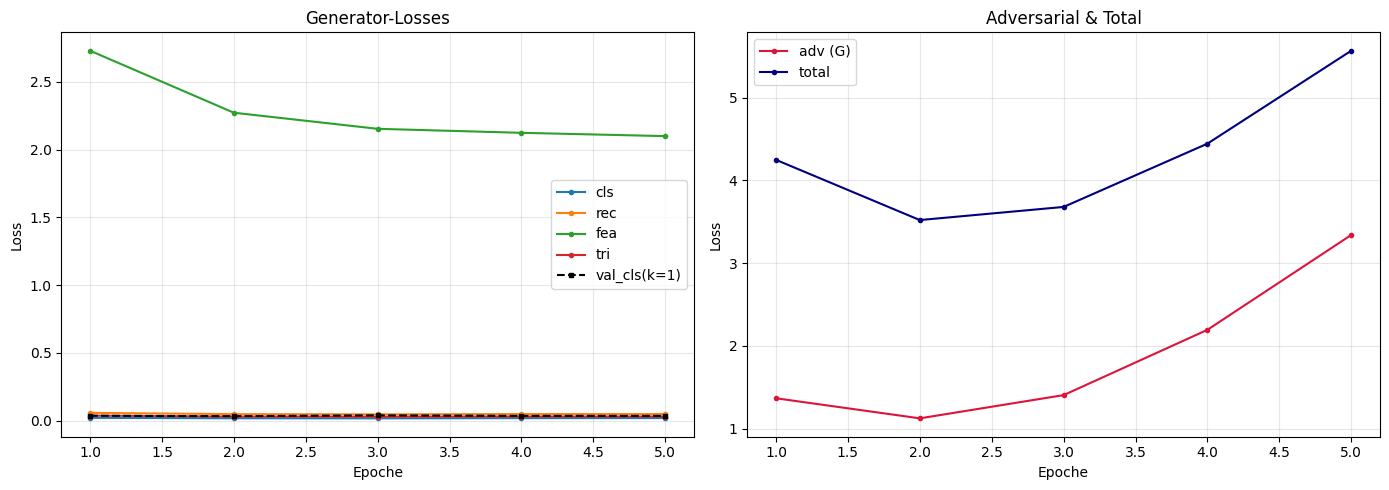

Kurven gespeichert ✓


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(hist['total'])+1)
for kk in ['cls','rec','fea','tri']:
    axes[0].plot(ep, hist[kk], 'o-', ms=3, label=kk)
axes[0].plot(ep, hist['val_cls'], 's--', ms=3, label='val_cls(k=1)', color='k')
axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Loss')
axes[0].set_title('Generator-Losses'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, hist['adv'], 'o-', ms=3, color='crimson', label='adv (G)')
axes[1].plot(ep, hist['total'], 'o-', ms=3, color='navy', label='total')
axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('Loss')
axes[1].set_title('Adversarial & Total'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/mirror_decoder_training_curves_xray.png', dpi=120, bbox_inches='tight')
plt.show()
print('Kurven gespeichert ✓')


## 12. Qualitätscheck — Rekonstruktion & CFE-Flip

CFE-Flip-Rate (k=1, dieser Batch): 37.5%


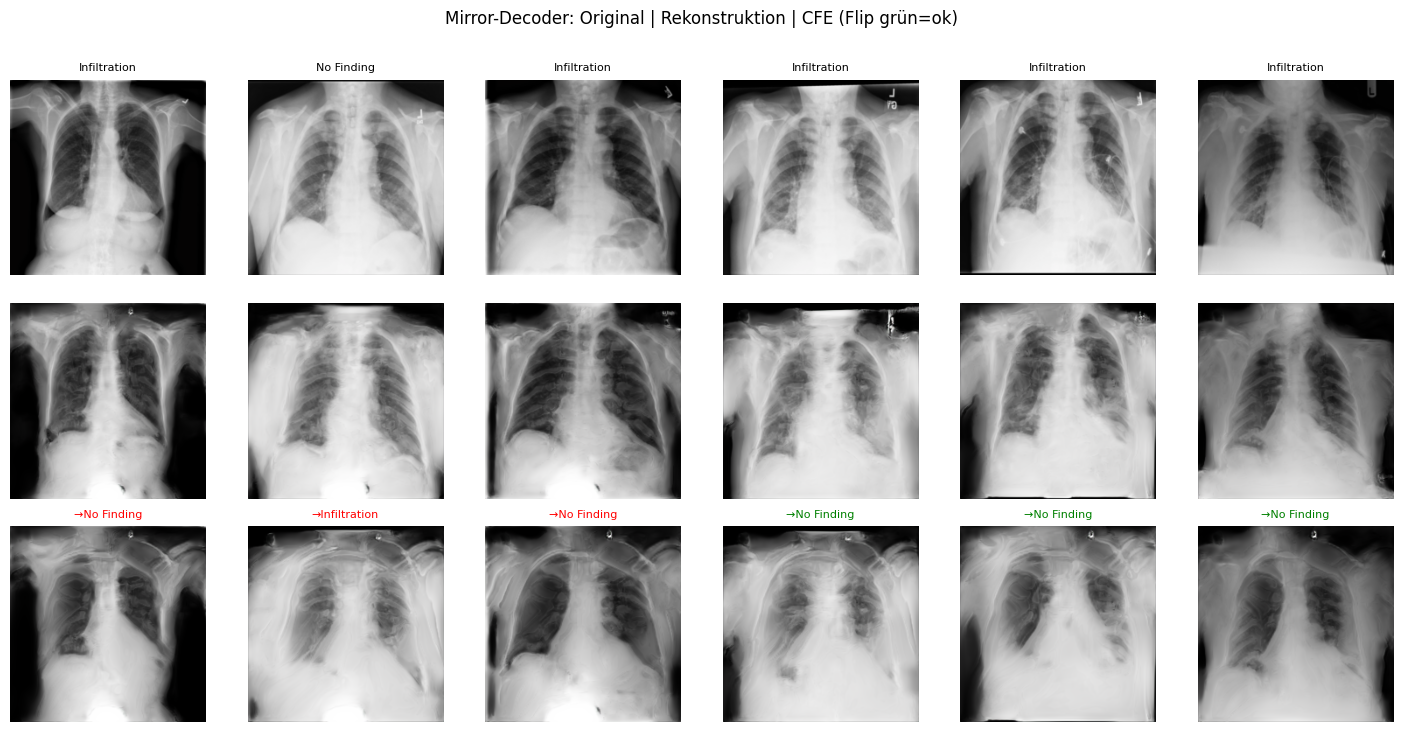

In [12]:
decoder.eval()
imgs, lbls, fnames = next(iter(val_loader))
imgs = imgs.to(DEVICE)
n = min(6, imgs.size(0))

with torch.no_grad():
    f1,f2,f3,f4 = extract_all_features(classifier, imgs)
    zs  = gap(f4); src = classifier(imgs).argmax(1); tgt = 1-src
    # Rekonstruktion k=0
    flk0,_ = compute_flk(f4, zs, Wm, bm, 0.0)
    xrec = tanh_to_img(decoder(flk0, f1, f2, f3, Wmat, 0.0, src, src))
    # CFE k=1
    flk1, zk1 = compute_flk(f4, zs, Wm, bm, 1.0)
    xcfe = tanh_to_img(decoder(flk1, f1, f2, f3, Wmat, 1.0, src, tgt))
    # Validity der dekodierten CFE
    cfe_pred = classifier(renormalise(xcfe)).argmax(1)
    flip = (cfe_pred == tgt).float().mean().item()

print(f'CFE-Flip-Rate (k=1, dieser Batch): {flip:.1%}')

fig, axes = plt.subplots(3, n, figsize=(n*2.4, 7.2))
orig = denormalise(imgs)
for i in range(n):
    axes[0,i].imshow(orig[i].cpu().permute(1,2,0).numpy()); axes[0,i].axis('off')
    axes[0,i].set_title(f'{CLASS_NAMES[src[i].item()]}', fontsize=8)
    axes[1,i].imshow(xrec[i].cpu().permute(1,2,0).numpy().clip(0,1)); axes[1,i].axis('off')
    axes[2,i].imshow(xcfe[i].cpu().permute(1,2,0).numpy().clip(0,1)); axes[2,i].axis('off')
    fl = 'green' if cfe_pred[i]==tgt[i] else 'red'
    axes[2,i].set_title(f'→{CLASS_NAMES[tgt[i].item()]}', fontsize=8, color=fl)
axes[0,0].set_ylabel('Original',    fontsize=9)
axes[1,0].set_ylabel('Rekon (k=0)', fontsize=9)
axes[2,0].set_ylabel('CFE (k=1)',   fontsize=9)
plt.suptitle('Mirror-Decoder: Original | Rekonstruktion | CFE (Flip grün=ok)', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/mirror_decoder_recon_check_xray.png', dpi=120, bbox_inches='tight')
plt.show()
